In [11]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.manifold import TSNE

DISTINCT_COLORS = [
    "#E6194B",  
    "#3CB44B", 
    "#4363D8", 
    "#F58231",  
    "#911EB4",  
]
SEED = 42

In [12]:
original_data   = np.load('../duomenys/original_data.npy')
labels          = np.load('../duomenys/ship-types.npy')
distance_matrix = np.load('../duomenys/dist_mat.npy')

In [13]:
unique_labels, labels_encoded = np.unique(labels, return_inverse=True)
label_names = {i: name for i, name in enumerate(unique_labels)}

n_samples = original_data.shape[0]
original_flat = original_data.reshape(n_samples, -1)

all_classes = np.unique(labels_encoded)
class_colors = {cls: DISTINCT_COLORS[i % len(DISTINCT_COLORS)]
                for i, cls in enumerate(all_classes)}

embedding = TSNE(
    perplexity=5,
    early_exaggeration=24,
    learning_rate=10,
    max_iter=500,
    n_components=2,
    random_state=SEED
).fit_transform(distance_matrix)

In [14]:
from sklearn.model_selection import train_test_split

original_flat = original_data.reshape((-1, original_data.shape[1]*original_data.shape[2]))
X_train, X_test, y_train, y_test, emb_train, emb_test = train_test_split(
    original_flat, labels_encoded, embedding, test_size=0.3, random_state=SEED, stratify=labels_encoded
)

In [15]:
import pandas as pd

In [16]:
from sklearn.metrics import confusion_matrix

In [17]:
def run_xgboost(X_train, X_test, y_train, y_test, label_names, **params):


    xgb = XGBClassifier(eval_metric='mlogloss', **params)
    xgb.fit(X_train, y_train)


    y_pred = xgb.predict(X_test)


    cm = confusion_matrix(y_test, y_pred)


    print(f"\n{'='*60}")
    for param, v in params.items():
        print(f"{param} : {v}")
    print(f"{'='*60}")
    print("Klasifikavimo lentele (true/pred)")
    cm_df = pd.DataFrame(cm)
    print(cm_df.to_string())


    n       = cm.sum()
    diag    = np.diag(cm)
    rowsums = cm.sum(axis=1)
    colsums = cm.sum(axis=0)


    precision = np.where(colsums > 0, diag / colsums, 0.0)
    recall    = np.where(rowsums > 0, diag / rowsums, 0.0)
    f1        = np.where((precision + recall) > 0,
                         2 * precision * recall / (precision + recall), 0.0)
    accuracy  = diag.sum() / n


    print("\nMetrikos kiekvienai klasei:")
    print(pd.DataFrame({"precision": precision, "recall": recall, "f1": f1},
                       index=[label_names[c] for c in range(5)]).round(4).to_string())
    print(f"\nAccuracy      : {accuracy:.4f}")
    print(f"Macro precision : {precision.mean():.4f}")
    print(f"Macro recall    : {recall.mean():.4f}")
    print(f"Macro F1        : {f1.mean():.4f}")


    return xgb

In [18]:
xgb_orig = run_xgboost(X_train, X_test, y_train, y_test, label_names)


Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  33   3   0   4   5
1   8  34   1   0   2
2   1   1  41   0   2
3   1   1   2  40   1
4   5   2   1   0  37

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.6875  0.7333  0.7097
Fishing       0.8293  0.7556  0.7907
Passenger     0.9111  0.9111  0.9111
Pilot         0.9091  0.8889  0.8989
Tanker        0.7872  0.8222  0.8043

Accuracy      : 0.8222
Macro precision : 0.8248
Macro recall    : 0.8222
Macro F1        : 0.8229


In [19]:
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(
    embedding, labels_encoded, test_size=0.3, random_state=SEED, stratify=labels_encoded
)

In [20]:
xgb_proj = run_xgboost(X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne, label_names)


Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  26   5   3   1  10
1   6  33   0   1   5
2   3   0  36   3   3
3   0   2   1  39   3
4   6   4   5   0  30

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.6341  0.5778  0.6047
Fishing       0.7500  0.7333  0.7416
Passenger     0.8000  0.8000  0.8000
Pilot         0.8864  0.8667  0.8764
Tanker        0.5882  0.6667  0.6250

Accuracy      : 0.7289
Macro precision : 0.7317
Macro recall    : 0.7289
Macro F1        : 0.7295


In [21]:
import matplotlib.colors as mcolors

In [22]:
def plot_decision_boundary(
    clf, 
    X_test_sc,
    y_test,
    label_names,
    title,
    ax,
    unique_classes,
    step=0.3
):

    x_min = X_test_sc[:,0].min() - 1
    x_max = X_test_sc[:,0].max() + 1
    y_min = X_test_sc[:,1].min() - 1
    y_max = X_test_sc[:,1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    class_to_idx = {c: i for i, c in enumerate(unique_classes)}
    Z_idx = np.array([class_to_idx[z] for z in Z]).reshape(xx.shape)
    n_classes = len(unique_classes)
    bg_cmap = mcolors.ListedColormap([class_colors[c] for c in unique_classes])
    ax.contourf(xx, yy, Z_idx, alpha=0.25, cmap=bg_cmap,
                levels=np.arange(-0.5, n_classes, 1))

    # Mokymo taškai
    for cls in unique_classes:
        mask = y_test == cls
        ax.scatter(X_test_sc[mask, 0], X_test_sc[mask, 1],
                   c=class_colors[cls], edgecolors='k', s=60,
                   label=label_names[cls], zorder=3)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(fontsize=7, loc="best")




In [23]:
import matplotlib.pyplot as plt

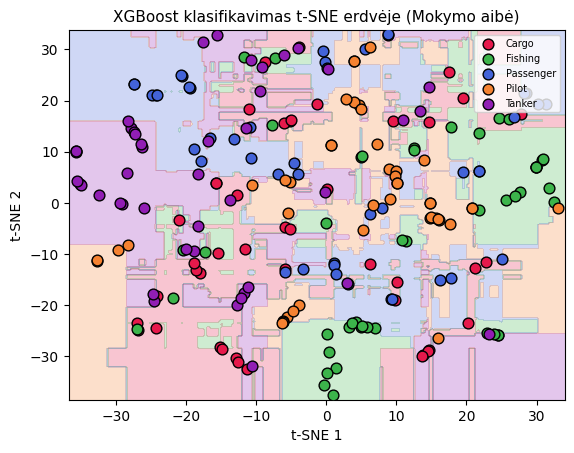

In [24]:
fig, ax = plt.subplots()

plot_decision_boundary(
    xgb_proj, X_test_tsne, y_test_tsne, label_names, unique_classes=all_classes,
    title="XGBoost klasifikavimas t-SNE erdvėje (Mokymo aibė)",
    ax=ax
)

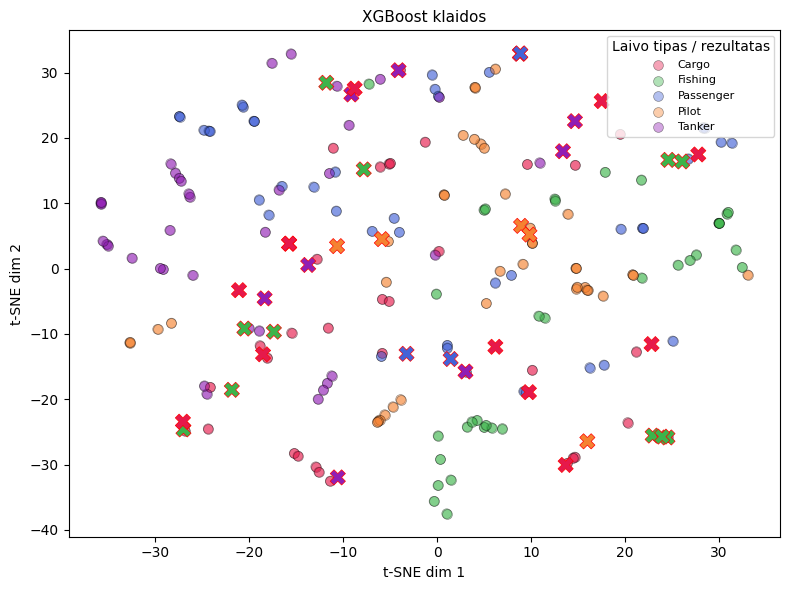

In [25]:
fig2, ax2 = plt.subplots(figsize=(8, 6))

unique_cls = np.unique(labels_encoded)
y_pred = xgb_orig.predict(X_test)
correct = y_pred == y_test 

# Teisingai klasifikuoti — permatomi (alpha=0.4)
ax2.scatter(emb_test[correct, 0], emb_test[correct, 1],
            c=[class_colors[c] for c in y_test[correct]],
            s=50, edgecolors='k', linewidths=0.5, marker='o', alpha=0.4, zorder=2)

for cls in unique_cls:
    mask = correct & (y_test == cls)
    ax2.scatter(
        emb_test[mask, 0], emb_test[mask, 1],
        c=class_colors[cls], s=50, edgecolors='k', linewidths=0.5,
        marker='o', alpha=0.4, zorder=2,
        label=unique_labels[cls]
    )

# Klaidingai klasifikuoti — ryškūs ir didesni (alpha=1.0, s=120)
ax2.scatter(
    emb_test[~correct, 0], emb_test[~correct, 1],
    c=[class_colors[c] for c in y_test[~correct]],
    s=120, edgecolors='red', linewidths=0.5, marker='X', alpha=1.0, zorder=3
)
ax2.legend(fontsize=8, loc='upper right', title="Laivo tipas / rezultatas")

ax2.set_title("XGBoost klaidos", fontsize=11)
ax2.set_xlabel("t-SNE dim 1")
ax2.set_ylabel("t-SNE dim 2")
plt.tight_layout()
# plt.savefig('./plots/knn_errors_orig.svg', format='svg')
plt.show()


In [26]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd

param_grid = {
    'n_estimators': [20, 75, 100, 200],
    'max_depth':    [3, 5, 8, 12],
    'learning_rate': [0.05, 0.1, 0.2],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=XGBClassifier(eval_metric='mlogloss', random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

# ── Results ───────────────────────────────────────────────────────────────────
print(f"Best params:  {grid_search.best_params_}")
print(f"Best CV acc:  {grid_search.best_score_:.4f}")

# Full results as a sorted DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)
cols = ['param_n_estimators', 'param_max_depth', 'param_learning_rate',
        'mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score']
print(results_df[cols].sort_values('rank_test_score').to_string(index=False))

# ── Best model ready to use ───────────────────────────────────────────────────
xgb_best = grid_search.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params:  {'learning_rate': 0.2, 'max_depth': 12, 'n_estimators': 100}
Best CV acc:  0.8171
 param_n_estimators  param_max_depth  param_learning_rate  mean_train_score  mean_test_score  std_test_score  rank_test_score
                100               12                 0.20          1.000000         0.817143        0.035328                1
                200               12                 0.20          1.000000         0.813333        0.035939                2
                200                8                 0.10          1.000000         0.811429        0.026530                3
                 75               12                 0.20          1.000000         0.809524        0.030713                4
                100                8                 0.20          1.000000         0.807619        0.023637                5
                200               12                 0.05          1.000000         0.

In [27]:
xgb_optim = run_xgboost(X_train, X_test, y_train, y_test, label_names,
                            **grid_search.best_params_)


learning_rate : 0.2
max_depth : 12
n_estimators : 100
Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  33   3   0   3   6
1   7  33   1   0   4
2   1   0  42   0   2
3   1   0   3  39   2
4   4   2   1   0  38

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.7174  0.7333  0.7253
Fishing       0.8684  0.7333  0.7952
Passenger     0.8936  0.9333  0.9130
Pilot         0.9286  0.8667  0.8966
Tanker        0.7308  0.8444  0.7835

Accuracy      : 0.8222
Macro precision : 0.8278
Macro recall    : 0.8222
Macro F1        : 0.8227


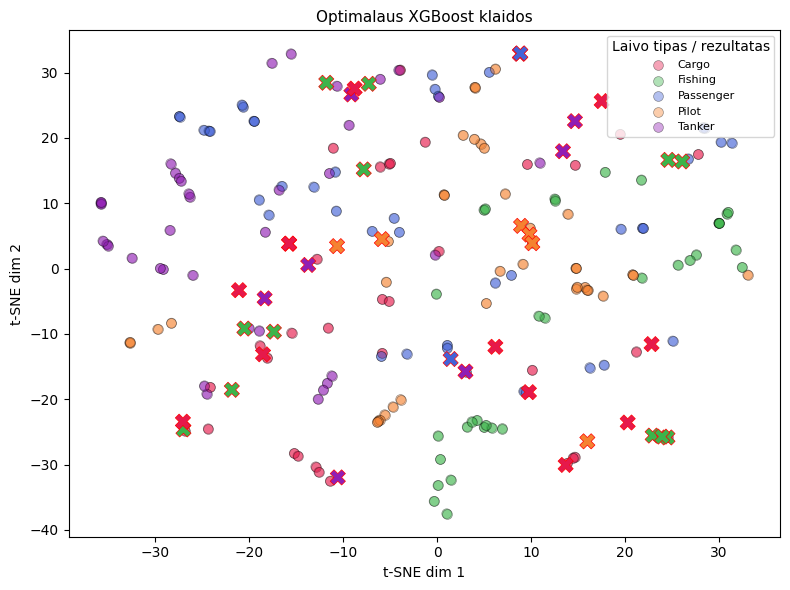

In [28]:
fig2, ax2 = plt.subplots(figsize=(8, 6))

unique_cls = np.unique(labels_encoded)
y_pred = xgb_optim.predict(X_test)
correct = y_pred == y_test 

# Teisingai klasifikuoti — permatomi (alpha=0.4)
ax2.scatter(emb_test[correct, 0], emb_test[correct, 1],
            c=[class_colors[c] for c in y_test[correct]],
            s=50, edgecolors='k', linewidths=0.5, marker='o', alpha=0.4, zorder=2)

for cls in unique_cls:
    mask = correct & (y_test == cls)
    ax2.scatter(
        emb_test[mask, 0], emb_test[mask, 1],
        c=class_colors[cls], s=50, edgecolors='k', linewidths=0.5,
        marker='o', alpha=0.4, zorder=2,
        label=unique_labels[cls]
    )

# Klaidingai klasifikuoti — ryškūs ir didesni (alpha=1.0, s=120)
ax2.scatter(
    emb_test[~correct, 0], emb_test[~correct, 1],
    c=[class_colors[c] for c in y_test[~correct]],
    s=120, edgecolors='red', linewidths=0.5, marker='X', alpha=1.0, zorder=3
)
ax2.legend(fontsize=8, loc='upper right', title="Laivo tipas / rezultatas")

ax2.set_title("Optimalaus XGBoost klaidos", fontsize=11)
ax2.set_xlabel("t-SNE dim 1")
ax2.set_ylabel("t-SNE dim 2")
plt.tight_layout()
# plt.savefig('./plots/knn_errors_orig.svg', format='svg')
plt.show()
